# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31502 entries, 4 to 35127
Data columns (total 75 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 31502 non-null  float64       
 1   CurrentDebt                            31502 non-null  float64       
 2   LongTermDebt                           31502 non-null  float64       
 3   TotalDebt                              31502 non-null  float64       
 4   StockholdersEquity                     31502 non-null  float64       
 5   TotalAssets                            31502 non-null  float64       
 6   CurrentAssets                          31502 non-null  float64       
 7   CurrentLiabilities                     31502 non-null  float64       
 8   TotalNoncurrentLiabilities             31502 non-null  float64       
 9   TotalLiabilities                       31502 non-null  float64    

## Feature Engineering

In [3]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [4]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Incluir las variables que tengan baja importancia para reducir el ruido (ej: importance < 0.01)
variables_no_significativas = [

]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Posibles labels:
    # 1) Ratios de valuación
    'BookToMarket', 
    'EarningsYield',
    'EbitdaYield',    
    # 2) Variables de tamaño (si se usan como label, quitar predictores RelativeAssets y RelativeRevenue para evitar Data Leakage)
    'MarketCap_Log1p',
    'EnterpriseValue_YeoTransformed',

    # Precios (no usar como labels, no tiene sentido predecir precios crudos teniendo multiples tickers)
    'Open',
    'Close',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource',
    'AverageDailyVolume_Lag1' # al igual que el precio, el volumen de acciones negociado no tiene sentido utilizar.
    ]

# Se define la variable objetivo y las variables predictoras
label = 'EarningsYield'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.2860


In [5]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: -8626.0128 ± 9333.1154


In [6]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
36,num__RelativeAssets,0.607018
41,cat__Industry,0.086055
4,num__ReturnOnEquity,0.065694
3,num__ReturnOnAssets,0.042388
14,num__CapitalExpenditure_TTM_YoY,0.033750
5,num__CurrentRatio,0.033481
40,cat__Sector,0.027416
1,num__OperatingMargins,0.025176
16,num__AverageDailyVolume_Lag1_YoY,0.022962
28,num__TotalRevenue_TTM_Acceleration,0.016714


In [7]:
feature_importance_df.tail(6)

,feature,importance
26,num__CapitalExpenditure_TTM_YoY_IsMissing,1.132387e-09
25,num__FreeCashFlow_TTM_YoY_IsMissing,8.233195e-10
18,num__TotalRevenue_TTM_QoQ_IsMissing,7.625774e-10
20,num__FreeCashFlow_TTM_QoQ_IsMissing,1.676682e-10
21,num__CapitalExpenditure_TTM_QoQ_IsMissing,5.934844e-11
35,num__ReturnIsMissing_Lag1,0.000000e+00


In [8]:
# Visualizar distribución de features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,31502.0,14.392642,19.929735,0.000000e+00,0.000000,5.000000,23.000000,69.000000
OperatingMargins,31502.0,0.141804,0.131205,-3.644850e-01,0.061368,0.124640,0.203180,0.629332
ProfitMargins,31502.0,0.092903,0.119095,-3.073560e-01,0.032503,0.081867,0.145784,0.487657
ReturnOnAssets,31502.0,0.188435,0.216094,-5.503380e-01,0.077670,0.167944,0.286896,0.915268
ReturnOnEquity,31502.0,0.579977,0.774153,-1.625241e+00,0.230980,0.469184,0.849463,2.705365
CurrentRatio,31502.0,1.733387,0.973652,8.650500e-02,1.084985,1.471137,2.130231,5.266517
NetDebtToEbitda,31502.0,0.825063,1.120785,-2.888239e+00,0.232701,0.680831,1.271282,4.387067
FcfToEbitda,31502.0,0.610896,0.648902,-1.231027e+00,0.347355,0.617942,0.872449,2.451314
TotalRevenue_TTM_YoY,31502.0,0.070967,0.135766,-3.134031e-01,0.012222,0.035381,0.120275,0.444498
TotalRevenue_TTM_QoQ,31502.0,0.019159,0.042429,-1.089564e-01,-0.001232,0.014371,0.034666,0.142446


## Aplicación del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [9]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train, X_test, y_train, y_test = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Se calculan los residuos y el Cluster: PositiveBias / NegativeBias según el signo de los residuos
resultados_agrupados = procesar_resultados_prediccion(
    y_test=y_test, 
    y_pred=y_pred, 
    tickers=tickers_test
)

# Visualizar los resultados de la predicción
visualizar_resultados_predicciones(resultados_agrupados)


Estadísticas por cluster (a nivel de Ticker):
Sesgos positivos: 297 tickers, residuo medio global: 0.0866
Sesgos negativos: 166 tickers, residuo medio global: -6.3310


In [10]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker  Predicted  Observed  Residuals      Cluster  PercentError
  LYFT   2.652252  1.417602   1.234650 PositiveBias     87.094276
    GT  -1.934786 -3.084121   1.149335 PositiveBias    -37.266222
  CNDT  -1.031172 -2.087004   1.055832 PositiveBias    -50.590783
  CNXC  -0.770828 -1.675192   0.904364 PositiveBias    -53.985718
  DECK   1.059660  0.234528   0.825132 PositiveBias    351.826833


In [11]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,AverageDailyVolume_Lag1_Acceleration,QuarterlyReturn_Lag1,ShortTermBeta,ReturnIsMissing_Lag1,RelativeAssets,RelativeRevenue,CapExToRevenue_Log1p,DebtToEquity_Log1p,MarketCap_Log1p,EnterpriseValue_YeoTransformed
0,LYFT,2.652252,1.417602,1.234650,PositiveBias,87.094276,1034.869,56.1170,986.6180,1042.735,...,-0.361304,0.002095,1.633202,0.0,0.000442,0.000441,0.008890,0.296096,8.705516,-0.387995
1,GT,-1.934786,-3.084121,1.149335,PositiveBias,-37.266222,723.000,1709.0000,5276.0000,6985.000,...,-0.535597,-0.151130,0.102682,0.0,0.000919,0.001232,0.041815,1.201540,7.555438,-0.364413
2,CNDT,-1.031172,-2.087004,1.055832,PositiveBias,-50.590783,228.000,23.0000,698.0000,721.000,...,-0.113828,-0.005848,3.063214,0.0,0.000119,0.000207,0.025150,0.753680,5.434063,-0.463114
3,CNXC,-0.770828,-1.675192,0.904364,PositiveBias,-53.985718,222.699,750.0000,3995.2530,4745.253,...,-1.629075,0.165033,0.423067,0.0,0.000531,0.000680,0.023601,0.993909,7.282784,-0.388763
4,DECK,1.059660,0.234528,0.825132,PositiveBias,351.826833,1907.249,75.0388,300.1552,375.194,...,-0.010588,0.090283,0.244609,0.0,0.000184,0.000393,0.014863,0.139848,9.587000,-0.315847


## Explicabilidad del Modelo (SHAP)

In [12]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'CNDT'

--- Explicación de la predicción para: CNDT ---


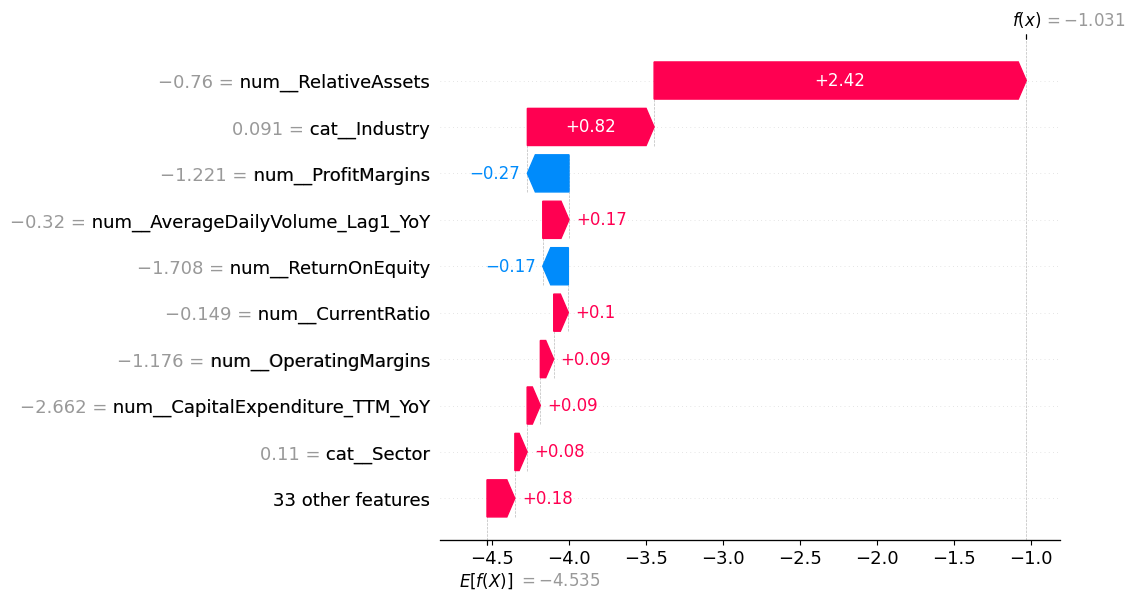

In [13]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [14]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)